   MSCI MOMENTUM vs 7-Year Strategy vs NIFTY INDEX 
  Warm-up: 2015–2017  |  Backtest + Plot: 2018–2025
  Rebalance: Semi-Annual  |  Universe: Nifty 50  |  15 Stocks



ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')


  Successfully loaded 49 stocks


Running MSCI Momentum Backtest (6M + 12M Blend)...
  Rebal 01 | 2015-01-30 | skipped (insufficient data)
  Rebal 02 | 2015-07-31 | stocks: 15 | kept: 15
  Rebal 03 | 2016-02-01 | stocks: 15 | kept: 15
  Rebal 04 | 2016-08-01 | stocks: 15 | kept: 15
  Rebal 05 | 2017-01-31 | stocks: 15 | kept: 15
  Rebal 06 | 2017-07-31 | stocks: 15 | kept: 15
  Rebal 07 | 2018-01-31 | stocks: 15 | kept: 15
  Rebal 08 | 2018-07-31 | stocks: 15 | kept: 15
  Rebal 09 | 2019-01-31 | stocks: 15 | kept: 15
  Rebal 10 | 2019-07-31 | stocks: 15 | kept: 15
  Rebal 11 | 2020-01-31 | stocks: 15 | kept: 15
  Rebal 12 | 2020-07-31 | stocks: 15 | kept: 15
  Rebal 13 | 2021-02-01 | stocks: 15 | kept: 15
  Rebal 14 | 2021-07-30 | stocks: 15 | kept: 15
  Rebal 15 | 2022-01-31 | stocks: 15 | kept: 15
  Rebal 16 | 2022-08-01 | stocks: 15 | kept: 15
  Rebal 17 | 2023-01-31 | stocks: 15 | kept: 15
  Rebal 18 | 2023-07-31 | stocks: 15 | kept: 15
  Rebal 19 | 2024-01-31 | stocks: 15 | kept: 

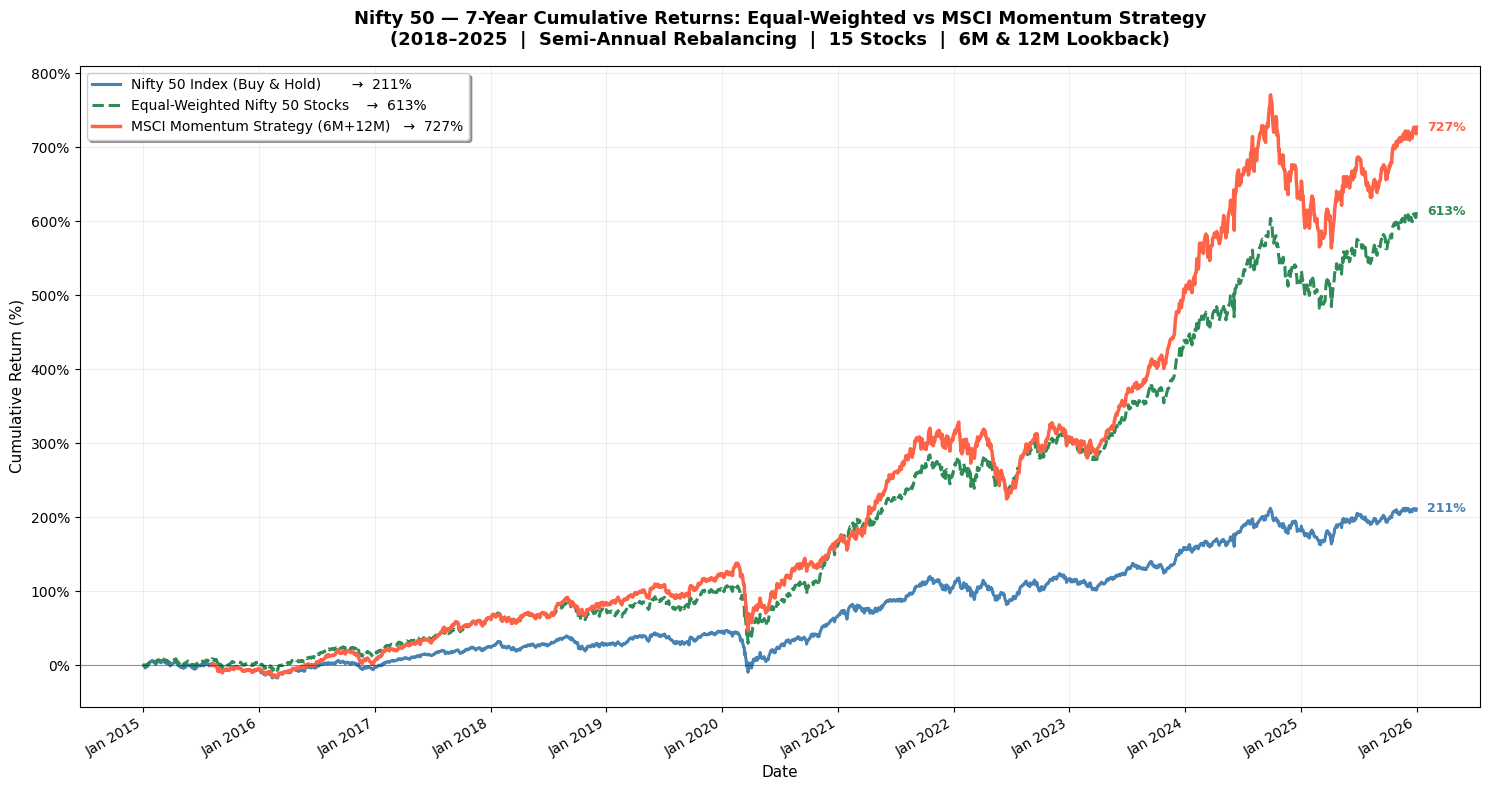

In [ ]:

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


#  CONFIGURING PERIOD TO GET BACKTESTING PERIOD DATA

WARMUP_START   = "2012-01-01"   # warm-up start
BACKTEST_START = "2015-01-01"   # backtest and plot from here
END_DATE       = "2026-01-01"
RISK_FREE_RATE = 0.065          # India MIBOR proxy (~6.5%)
TARGET_STOCKS  = 15             # 30% of Nifty 50
REBAL_FREQ     = "6ME"          # semi-annual rebalancing

NIFTY50_TICKERS = [
    'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'HINDUNILVR.NS',
    'ICICIBANK.NS', 'KOTAKBANK.NS', 'SBIN.NS', 'BHARTIARTL.NS', 'ITC.NS',
    'BAJFINANCE.NS', 'ASIANPAINT.NS', 'MARUTI.NS', 'HCLTECH.NS', 'AXISBANK.NS',
    'SUNPHARMA.NS', 'ULTRACEMCO.NS', 'TITAN.NS', 'NESTLEIND.NS', 'WIPRO.NS',
    'LT.NS', 'TECHM.NS', 'NTPC.NS', 'ONGC.NS', 'POWERGRID.NS', 'BAJAJFINSV.NS',
    'M&M.NS', 'TATASTEEL.NS', 'ADANIPORTS.NS', 'HINDALCO.NS', 'INDUSINDBK.NS',
    'COALINDIA.NS', 'DIVISLAB.NS', 'BRITANNIA.NS', 'EICHERMOT.NS', 'DRREDDY.NS',
    'GRASIM.NS', 'JSWSTEEL.NS', 'HEROMOTOCO.NS', 'CIPLA.NS', 'BAJAJ-AUTO.NS',
    'TATACONSUM.NS', 'APOLLOHOSP.NS', 'BPCL.NS', 'SBILIFE.NS', 'HDFCLIFE.NS',
    'TATAMOTORS.NS', 'SHRIRAMFIN.NS', 'TRENT.NS', 'ADANIENT.NS'
]

#  Download from 2015 so warm-up data is available for volatility & momentum.

def download_all_data():
    print(f"Downloading Nifty 50 index ({WARMUP_START} to {END_DATE})...")
    nifty_raw = yf.download('^NSEI', start=WARMUP_START, end=END_DATE,
                             progress=False, auto_adjust=True)
    nifty = nifty_raw['Close'].squeeze()

    print(f"Downloading {len(NIFTY50_TICKERS)} constituent stocks ({WARMUP_START} to {END_DATE})...")
    stock_data = {}
    for ticker in NIFTY50_TICKERS:
        try:
            raw = yf.download(ticker, start=WARMUP_START, end=END_DATE,
                               progress=False, auto_adjust=True)
            if not raw.empty:
                stock_data[ticker] = raw['Close'].squeeze()
        except Exception:
            pass

    prices = pd.DataFrame(stock_data).dropna(how='all', axis=1)
    print(f"  Successfully loaded {prices.shape[1]} stocks\n")
    return nifty, prices

#  STEP 2 — BASELINES

def nifty_cumulative(nifty_series):

    nifty_bt  = nifty_series.loc[BACKTEST_START:]
    daily_ret = nifty_bt.pct_change().fillna(0)
    return (1 + daily_ret).cumprod() - 1


def equal_weighted_cumulative(prices):

    prices_bt = prices.loc[BACKTEST_START:]
    daily_ret = prices_bt.pct_change().fillna(0)
    port_ret  = daily_ret.mean(axis=1)
    return (1 + port_ret).cumprod() - 1


#  STEP 3 — MSCI MOMENTUM SCORING

def compute_3yr_volatility(prices_slice):

    weekly = prices_slice.resample('W-FRI').last().ffill()
    vol_3y = weekly.pct_change().rolling(window=156).std().iloc[-1] * np.sqrt(52)
    return vol_3y


def compute_momentum_scores(prices_slice, rf_rate):

    # Need at least 3 years of data for vol + 13 months for 12M lookback
    if len(prices_slice) < 800:
        return pd.DataFrame()

    vol_3y = compute_3yr_volatility(prices_slice)

    # Price levels at key lookback points (in trading days)
    p_1m  = prices_slice.shift(21).iloc[-1]    # 1 month ago  — skip recent reversal
    p_7m  = prices_slice.shift(147).iloc[-1]   # 7 months ago — 6M lookback start
    p_13m = prices_slice.shift(273).iloc[-1]   # 13 months ago — 12M lookback start

    # Excess return over risk-free rate
    mom_6m  = (p_1m / p_7m  - 1) - (rf_rate * 0.5)
    mom_12m = (p_1m / p_13m - 1) - rf_rate

    # Risk-adjusted momentum
    ram_6m  = mom_6m  / vol_3y
    ram_12m = mom_12m / vol_3y

    # Cross-sectional z-scores
    z_6m  = (ram_6m  - ram_6m.mean())  / ram_6m.std()
    z_12m = (ram_12m - ram_12m.mean()) / ram_12m.std()

    # Blend and winsorise
    z_combined = (0.6 * z_6m + 0.4 * z_12m).clip(-3, 3)

    # Convert to always-positive momentum score
    score = np.where(z_combined >= 0,
                     1 + z_combined,
                     1 / (1 - z_combined))

    return pd.DataFrame({
        'z_combined':     z_combined,
        'momentum_score': score
    }, index=ram_6m.index).dropna().sort_values('z_combined', ascending=False)


#  STEP 4 — PORTFOLIO CONSTRUCTION


def select_and_weight(scores, prev_holdings, target=15, buffer_ratio=0.5):

    ranked = scores.index.tolist()
    buffer = int(target * buffer_ratio)

    priority  = ranked[:target - buffer]
    kept      = [s for s in prev_holdings
                 if s in ranked and ranked.index(s) < target + buffer]
    new_adds  = [s for s in priority if s not in kept]
    selected  = (kept + new_adds)[:target]

    if len(selected) < target:
        extras   = [s for s in ranked if s not in selected]
        selected += extras[:target - len(selected)]

    weights = scores.loc[selected, 'momentum_score']
    weights = weights.clip(upper=weights.sum() * 0.05)   # 5% weight cap
    return selected, weights / weights.sum()

#  STEP 5 — BACKTEST ENGINE

def run_backtest(prices, rf_rate=RISK_FREE_RATE,
                 target=TARGET_STOCKS, rebal_freq=REBAL_FREQ):
    print("\nRunning MSCI Momentum Backtest (6M + 12M Blend)...")

    # Rebalance dates within the BACKTEST window only
    rebal_raw   = pd.date_range(start=BACKTEST_START, end=END_DATE, freq=rebal_freq)
    rebal_dates = []
    for d in rebal_raw:
        idx = prices.index.get_indexer([d], method='nearest')[0]
        if idx >= 0:
            rebal_dates.append(prices.index[idx])

    all_returns   = []
    prev_holdings = []

    for i, rdate in enumerate(rebal_dates):
        # Pass ALL data up to rebal date (including warm-up) for scoring
        scores = compute_momentum_scores(prices.loc[:rdate], rf_rate)

        if scores.empty:
            print(f"  Rebal {i+1:02d} | {rdate.date()} | skipped (insufficient data)")
            continue

        selected, weights = select_and_weight(scores, prev_holdings, target)

        period_end = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else prices.index[-1]

        period_ret = prices.loc[rdate:period_end, selected].pct_change()
        port_ret   = period_ret.multiply(weights, axis=1).sum(axis=1).iloc[1:]
        all_returns.append(port_ret)

        prev_holdings = selected
        kept_count    = len([s for s in selected if s in prev_holdings])
        print(f"  Rebal {i+1:02d} | {rdate.date()} | stocks: {len(selected)} | kept: {kept_count}")

    combined = pd.concat(all_returns).sort_index()
    cum_ret  = (1 + combined).cumprod() - 1
    print(f"  Momentum final cumulative return: {cum_ret.iloc[-1]:.2%}")
    return cum_ret

#  STEP 6 — PERFORMANCE SUMMARY TABLE

def print_summary(nifty_cum, ew_cum, mom_cum, nifty_series, prices):

    def metrics(daily_ret):
        ann_ret = daily_ret.mean() * 252
        ann_vol = daily_ret.std()  * np.sqrt(252)
        sharpe  = (ann_ret - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0
        wealth  = (1 + daily_ret).cumprod()
        max_dd  = ((wealth - wealth.expanding().max()) / wealth.expanding().max()).min()
        return ann_ret, ann_vol, sharpe, max_dd

    nifty_ret = nifty_series.loc[BACKTEST_START:].pct_change().fillna(0)
    ew_ret    = prices.loc[BACKTEST_START:].pct_change().fillna(0).mean(axis=1)
    mom_ret   = mom_cum.diff().fillna(mom_cum.iloc[0])

    rows = [
        ("Nifty 50 Index",         nifty_cum, nifty_ret.reindex(nifty_cum.index).fillna(0)),
        ("Equal-Weighted Stocks",  ew_cum,    ew_ret.reindex(ew_cum.index).fillna(0)),
        ("MSCI Momentum (6M+12M)", mom_cum,   mom_ret),
    ]

    print(f"\n{'='*70}")
    print(f"{'PERFORMANCE SUMMARY (2018–2025)':^70}")
    print(f"{'='*70}")
    print(f"{'Strategy':<26} {'Total':>8} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>8} {'Max DD':>8}")
    print(f"{'-'*70}")
    for name, cum, daily in rows:
        ar, av, sh, md = metrics(daily)
        print(f"{name:<26} {cum.iloc[-1]:>8.2%} {ar:>8.2%} {av:>8.2%} {sh:>8.2f} {md:>8.2%}")
    print(f"{'='*70}\n")


#  STEP 7 — PLOT COMBINED CHART

def plot_combined_chart(nifty_cum, ew_cum, mom_cum):
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.plot(nifty_cum.index, nifty_cum * 100,
            color='steelblue', linewidth=2.2,
            label=f'Nifty 50 Index (Buy & Hold)       →  {nifty_cum.iloc[-1]*100:.0f}%')

    ax.plot(ew_cum.index, ew_cum * 100,
            color='seagreen', linewidth=2.2, linestyle='--',
            label=f'Equal-Weighted Nifty 50 Stocks    →  {ew_cum.iloc[-1]*100:.0f}%')

    ax.plot(mom_cum.index, mom_cum * 100,
            color='tomato', linewidth=2.5,
            label=f'MSCI Momentum Strategy (6M+12M)   →  {mom_cum.iloc[-1]*100:.0f}%')

    # Zero reference line
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)

    # End-of-line value annotations
    for series, color in [(nifty_cum, 'steelblue'), (ew_cum, 'seagreen'), (mom_cum, 'tomato')]:
        ax.annotate(f"{series.iloc[-1]*100:.0f}%",
                    xy=(series.index[-1], series.iloc[-1] * 100),
                    xytext=(8, 0), textcoords='offset points',
                    fontsize=9, color=color, fontweight='bold', va='center')

    # Axes formatting
    ax.set_title(
        'Nifty 50 — 7-Year Cumulative Returns: Equal-Weighted vs MSCI Momentum Strategy\n'
        ,
        fontsize=13, fontweight='bold', pad=15
    )
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Cumulative Return (%)', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.xticks(rotation=30, ha='right')

    ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=10, fancybox=True)
    ax.grid(True, alpha=0.3, linewidth=0.5)

    plt.tight_layout()
    plt.savefig('combined_chart.png', dpi=150, bbox_inches='tight')
    print("Chart saved as: combined_7yr_chart.png")
    plt.show()

#  MAIN

def main():
    print("=" * 65)
    print("   MSCI MOMENTUM vs 7-Year Strategy vs NIFTY INDEX ")
    print("  Warm-up: 2015–2017  |  Backtest + Plot: 2018–2025")
    print("  Rebalance: Semi-Annual  |  Universe: Nifty 50  |  15 Stocks")
    print("=" * 65 + "\n")

    # Step 1: Download all data (including 2015–2017 warm-up)
    nifty, prices = download_all_data()

    # Step 2: Baselines — trimmed to 2018 for plotting
    nifty_cum = nifty_cumulative(nifty)
    ew_cum    = equal_weighted_cumulative(prices)

    # Step 3: MSCI Momentum — rebalances from 2018, scores use full history
    mom_cum = run_backtest(prices)

    # Step 4: Print summary table
    print_summary(nifty_cum, ew_cum, mom_cum, nifty, prices)

    # Step 5: Plot all 3 on one chart
    plot_combined_chart(nifty_cum, ew_cum, mom_cum)


if __name__ == "__main__":
    main()